# RESULTS

**Research Question:** How does stress in the non-financial commercial paper market influence firms' working capital management and supply-chain operations?

**Scope:** Final analysis across the matched treatment-control panel of non-financial CP issuers, covering the GFC (2007–2008) and COVID-19 (2019–2020) stress episodes. Produces all descriptive statistics, difference-in-differences estimates, and figures.

**Output:** Tables and figures saved to `output/`, ready for thesis write-up.

## Section 1 – Imports & Configuration

In [1]:
# Imports
import warnings
warnings.filterwarnings('ignore')

# Core Data
import numpy as np
import pandas as pd

# File system & config
import sys
from pathlib import Path

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

# Econometrics
import statsmodels.formula.api as smf
from statsmodels.stats.sandwich_covariance import cov_cluster
from scipy import stats
from scipy.stats import ttest_ind, sem, t as t_dist
from linearmodels.panel import PanelOLS, PooledOLS

# Configuration
sys.path.insert(0, str(Path().resolve().parent))
from config import *

plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'font.size':         10,
})

COLOR_T = '#C0392B'
COLOR_C = '#2980B9'

## Section 2 — Analysis Panel

Loads upstream outputs, merges the CSI at quarterly frequency, and trims to the analysis window.

In [2]:
# CELL 2.1 — Load upstream outputs

panel    = pd.read_csv(DATA_DIR / 'WR_wc_panel_enriched.csv', parse_dates=['datadate'])
matches  = pd.read_csv(DATA_DIR / 'WR_control_matches.csv')
csi      = pd.read_csv(DATA_DIR / 'FR_csi.csv', parse_dates=['date'])
episodes = pd.read_csv(DATA_DIR / 'FR_stress_episodes.csv', parse_dates=['start', 'end', 'peak_date'])
master   = pd.read_csv(DATA_DIR / 'WR_cp_master_sample.csv')

print(f"Panel        : {len(panel):>7,} rows | {panel['gvkey'].nunique()} firms | "
      f"{panel['datadate'].min().date()} → {panel['datadate'].max().date()}")
print(f"  treatment  : {(panel['group']=='treatment').sum():>7,} rows | "
      f"{panel[panel['group']=='treatment']['gvkey'].nunique()} firms")
print(f"  control    : {(panel['group']=='control').sum():>7,} rows | "
      f"{panel[panel['group']=='control']['gvkey'].nunique()} firms")
print(f"Matches      : {len(matches):>7,} rows | "
      f"{matches['treatment_gvkey'].nunique()} treatment → "
      f"{matches['control_gvkey'].nunique()} control firms")
print(f"CSI          : {len(csi):>7,} weeks | "
      f"{csi['date'].min().date()} → {csi['date'].max().date()}")
print(f"Episodes     : {len(episodes)} stress episodes")
print(f"Master       : {len(master):>7,} rows | {master['gvkey'].nunique()} firms")

Panel        :  46,974 rows | 550 firms | 2000-01-31 → 2025-12-31
  treatment  :  22,835 rows | 245 firms
  control    :  24,139 rows | 305 firms
Matches      :     519 rows | 191 treatment → 305 control firms
CSI          :   1,380 weeks | 2000-01-05 → 2026-06-10
Episodes     : 23 stress episodes
Master       :     311 rows | 246 firms


In [3]:
# CELL 2.2 — Aggregate CSI to quarterly and merge

def flag_stress(date, episodes):
    for _, ep in episodes.iterrows():
        if ep['start'] <= date <= ep['end']:
            return 1
    return 0

csi['year']       = csi['date'].dt.year
csi['quarter']    = csi['date'].dt.quarter
csi['in_episode'] = csi['date'].apply(lambda d: flag_stress(d, episodes))

csi_q = (
    csi
    .groupby(['year', 'quarter'])
    .agg(
        csi_mean       = ('CSI', 'mean'),
        csi_max        = ('CSI', 'max'),
        stress_binary  = ('in_episode', 'max'),
        n_stress_weeks = ('in_episode', 'sum'),
    )
    .reset_index()
    .rename(columns={'year': 'fyearq', 'quarter': 'fqtr'})
)

panel = panel.merge(
    csi_q[['fyearq', 'fqtr', 'csi_mean', 'csi_max', 'stress_binary', 'n_stress_weeks']],
    on=['fyearq', 'fqtr'],
    how='left'
)

print(f"NaN in csi_max after merge: {panel['csi_max'].isna().sum()} rows")

NaN in csi_max after merge: 52 rows


In [4]:
# CELL 2.3 — Analysis variables and trim to analysis window

panel['treated'] = (panel['group'] == 'treatment').astype(int)
panel['yq']      = panel['fyearq'].astype(str) + '-Q' + panel['fqtr'].astype(str)

matched_firms              = set(matches['treatment_gvkey']) | set(matches['control_gvkey'])
panel['in_matched_sample'] = panel['gvkey'].isin(matched_firms).astype(int)

panel = panel[
    panel['csi_max'].notna() &
    panel['fyearq'].between(2000, 2024) &
    panel['fqtr'].notna()
].copy()

panel['fqtr'] = panel['fqtr'].astype(int)

print(f"Rows        : {len(panel):,}")
print(f"Firms       : {panel['gvkey'].nunique()}")
print(f"Treatment   : {panel[panel['treated']==1]['gvkey'].nunique()} firms, {(panel['treated']==1).sum():,} obs")
print(f"Control     : {panel[panel['treated']==0]['gvkey'].nunique()} firms, {(panel['treated']==0).sum():,} obs")
print(f"Date range  : {panel['datadate'].min().date()} → {panel['datadate'].max().date()}")
print(f"Stressed obs: {int(panel['stress_binary'].sum()):,} ({panel['stress_binary'].mean()*100:.1f}%)")

Rows        : 45,465
Firms       : 550
Treatment   : 245 firms, 21,997 obs
Control     : 305 firms, 23,468 obs
Date range  : 2000-01-31 → 2025-05-31
Stressed obs: 12,854 (28.3%)


## Section 3 — Descriptive Statistics

Summary statistics and raw trends for working capital outcomes and capital structure, comparing treatment and control groups across the full sample period.

- **3.1** — Working capital summary statistics
- **3.2** — Working capital trends over time
- **3.3** — Capital structure summary statistics

In [5]:
# CELL 3.1 — Working capital summary statistics

OUTCOMES = ['ccc', 'dso', 'dpo', 'dio', 'nwc_ratio']
CONTROLS = ['log_assets', 'leverage']
ALL_VARS = OUTCOMES + CONTROLS

LABELS = {
    'ccc'       : 'Cash Conversion Cycle (days)',
    'dso'       : 'Days Sales Outstanding (days)',
    'dpo'       : 'Days Payable Outstanding (days)',
    'dio'       : 'Days Inventory Outstanding (days)',
    'nwc_ratio' : 'NWC / Total Assets',
    'log_assets': 'Log Total Assets',
    'leverage'  : 'Leverage (debt / assets)',
}

treat = panel[panel['treated'] == 1]
ctrl  = panel[panel['treated'] == 0]

rows = []
for var in ALL_VARS:
    t_vals = treat[var].dropna()
    c_vals = ctrl[var].dropna()
    _, pval = ttest_ind(t_vals, c_vals, equal_var=False)
    stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
    rows.append({
        'Variable' : LABELS[var],
        'T mean'   : f"{t_vals.mean():.2f}",
        'T sd'     : f"{t_vals.std():.2f}",
        'T N'      : f"{len(t_vals):,}",
        'C mean'   : f"{c_vals.mean():.2f}",
        'C sd'     : f"{c_vals.std():.2f}",
        'C N'      : f"{len(c_vals):,}",
        'Diff'     : f"{t_vals.mean() - c_vals.mean():.2f}{stars}",
    })

sumstats = pd.DataFrame(rows)
print("Summary Statistics: Treatment vs Control")
print("=" * 95)
print(sumstats.to_string(index=False))
print("\nSignificance: *** p<0.01, ** p<0.05, * p<0.1 (Welch t-test, unpooled variance)")

sumstats.to_csv(OUTPUT_DIR / 'RE_summary_stats.csv', index=False)
print(f"\nSaved → RE_summary_stats.csv")

Summary Statistics: Treatment vs Control
                         Variable T mean   T sd    T N C mean   C sd    C N     Diff
     Cash Conversion Cycle (days)  69.82 101.72 21,018  70.14 100.52 21,910    -0.32
    Days Sales Outstanding (days)  58.50  47.12 21,504  56.10  39.25 22,628  2.41***
  Days Payable Outstanding (days)  68.94  63.16 21,686  65.12  67.61 22,801  3.82***
Days Inventory Outstanding (days)  81.78  87.26 21,303  80.20  86.43 22,178    1.58*
               NWC / Total Assets   0.13   0.16 21,802   0.17   0.17 22,054 -0.04***
                 Log Total Assets   9.51   1.39 21,802   8.53   1.24 22,910  0.98***
         Leverage (debt / assets)   0.30   0.16 21,802   0.30   0.18 22,910  0.01***

Significance: *** p<0.01, ** p<0.05, * p<0.1 (Welch t-test, unpooled variance)

Saved → RE_summary_stats.csv


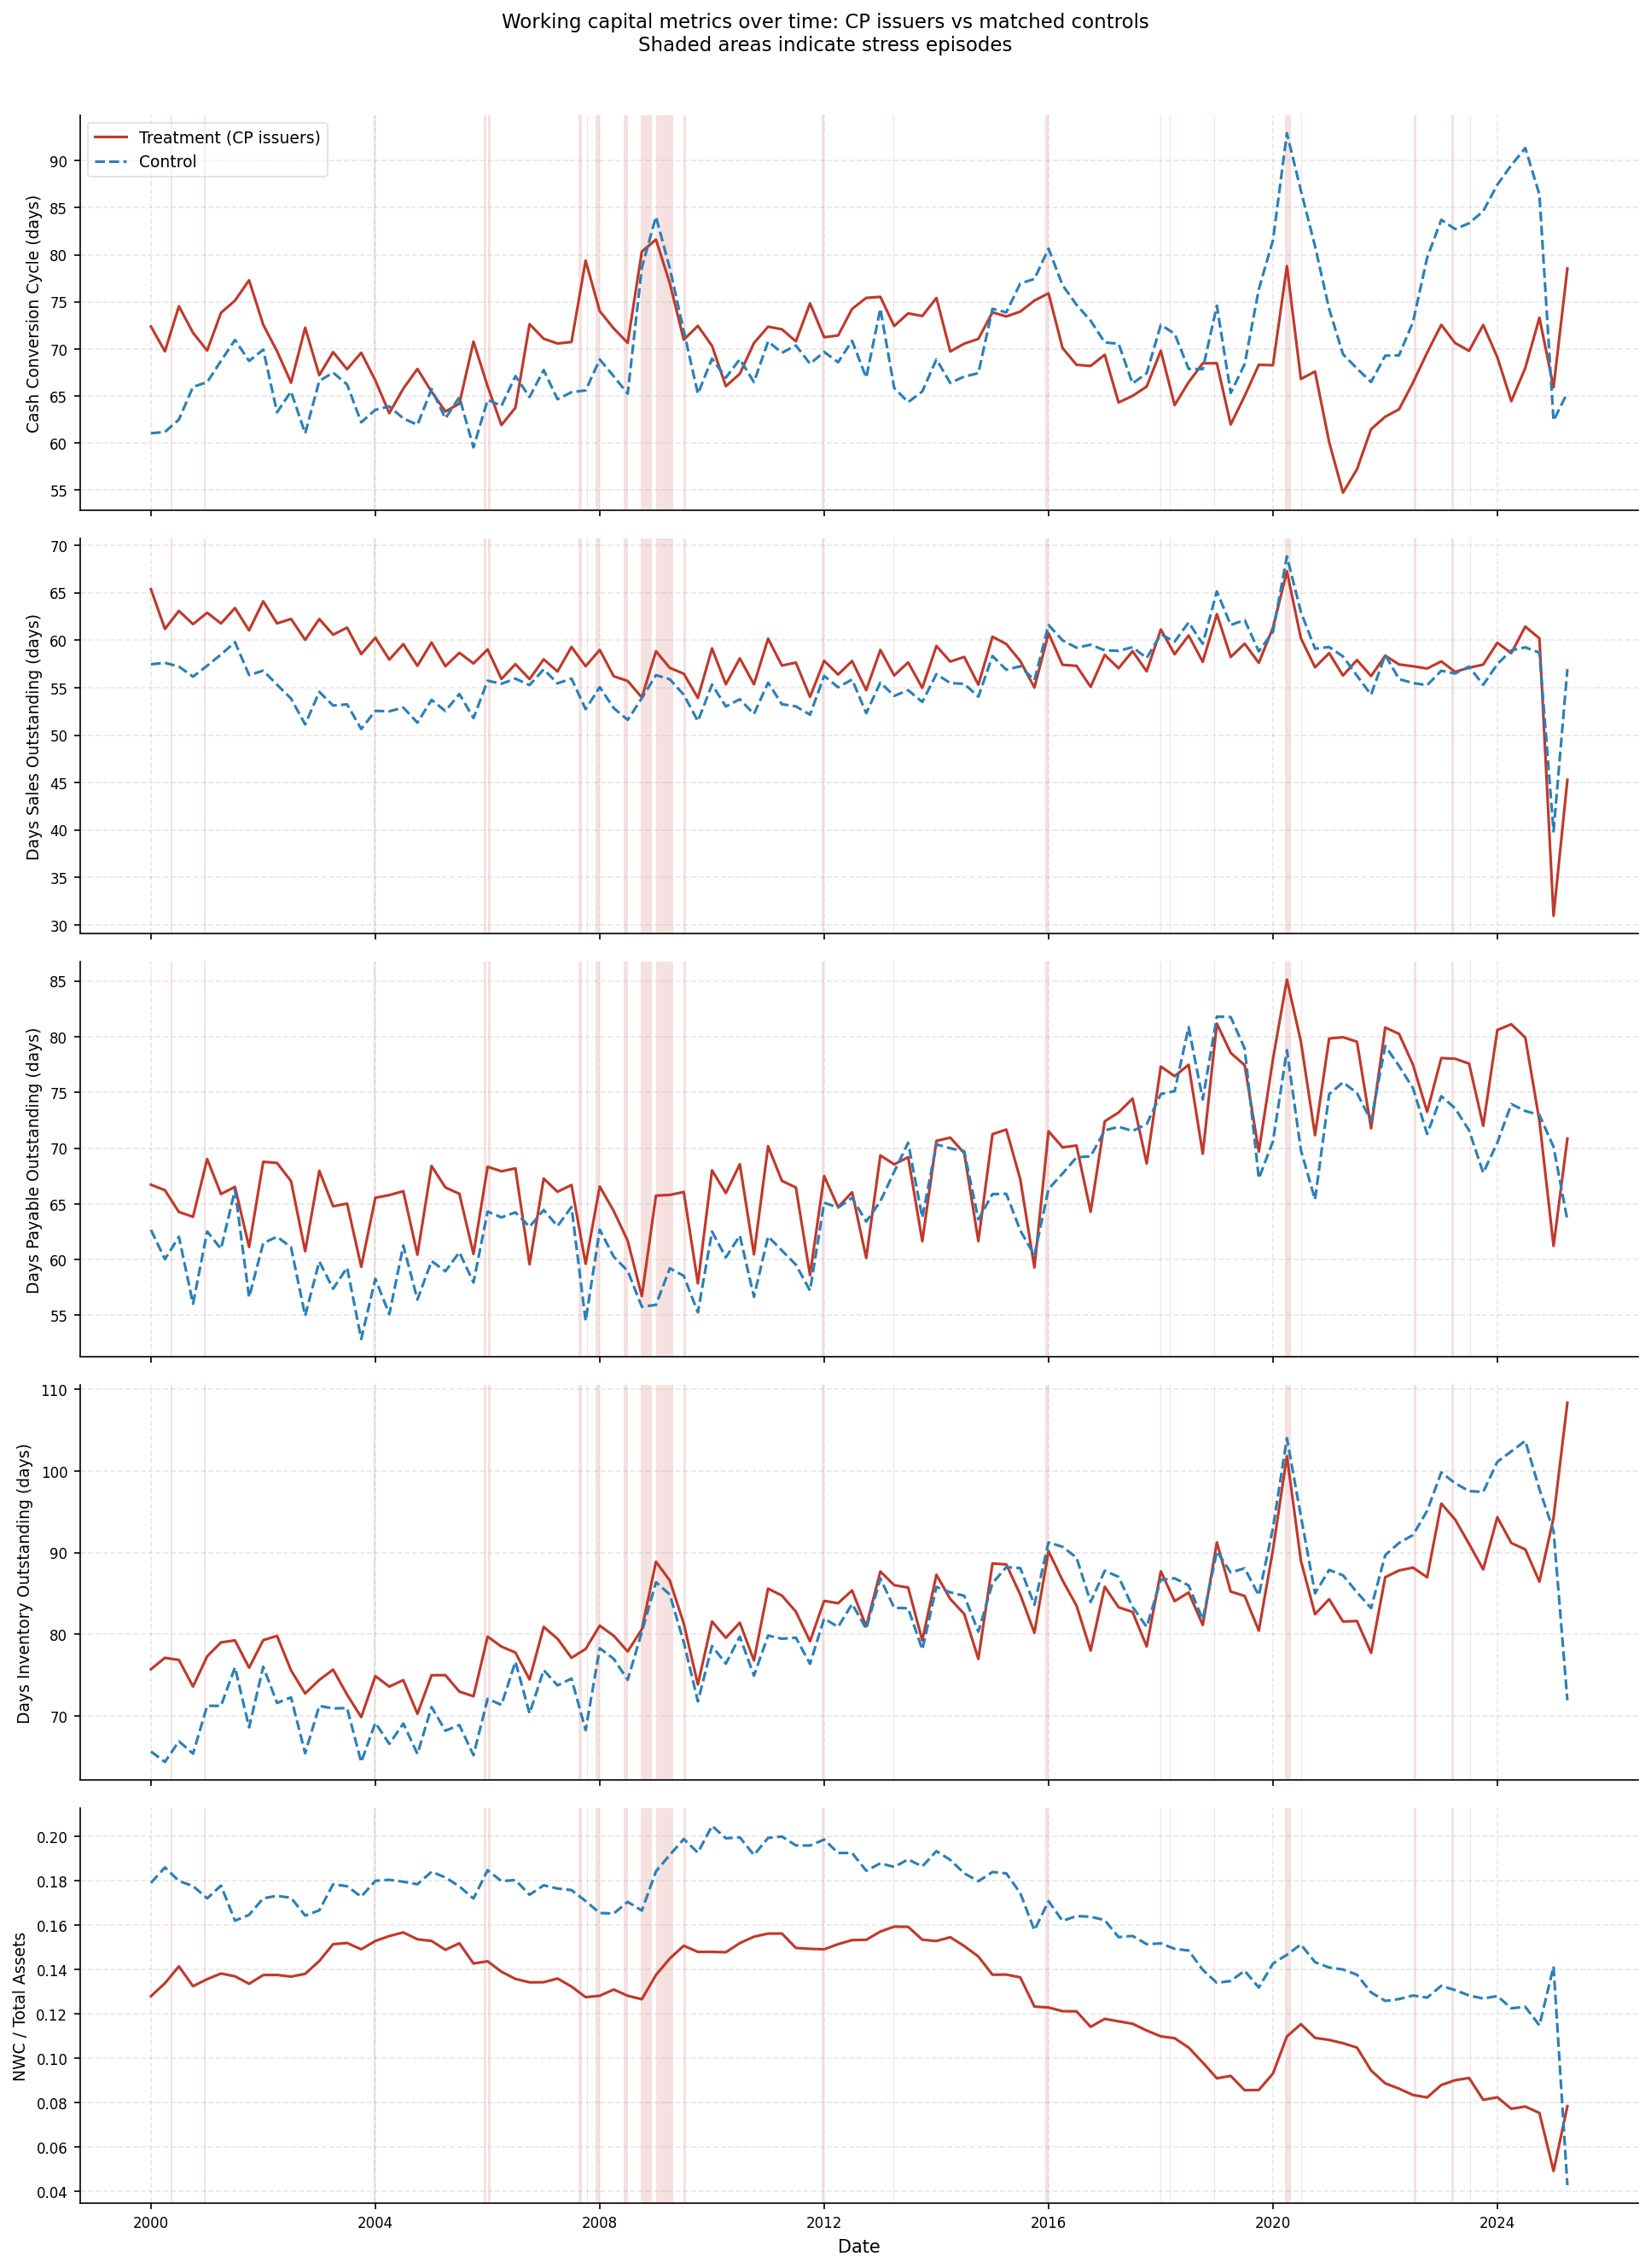

Saved → RE_wc_trends.png


In [6]:
# CELL 3.2 — Working capital trends over time

OUTCOMES_PLOT = {
    'ccc'      : 'Cash Conversion Cycle (days)',
    'dso'      : 'Days Sales Outstanding (days)',
    'dpo'      : 'Days Payable Outstanding (days)',
    'dio'      : 'Days Inventory Outstanding (days)',
    'nwc_ratio': 'NWC / Total Assets',
}

panel['date_q'] = pd.PeriodIndex(panel['datadate'], freq='Q').to_timestamp()

means = (
    panel.groupby(['date_q', 'treated'])[list(OUTCOMES_PLOT.keys())]
    .mean()
    .reset_index()
)

treat_means = means[means['treated'] == 1].set_index('date_q')
ctrl_means  = means[means['treated'] == 0].set_index('date_q')

fig, axes = plt.subplots(len(OUTCOMES_PLOT), 1, figsize=(13, 3.5 * len(OUTCOMES_PLOT)),
                         sharex=True)

for ax, (var, label) in zip(axes, OUTCOMES_PLOT.items()):
    for _, ep in episodes.iterrows():
        ax.axvspan(ep['start'], ep['end'], alpha=0.15, color=COLOR_T, linewidth=0)

    ax.plot(treat_means.index, treat_means[var],
            color=COLOR_T, linewidth=1.5, label='Treatment (CP issuers)')
    ax.plot(ctrl_means.index,  ctrl_means[var],
            color=COLOR_C, linewidth=1.5, label='Control', linestyle='--')

    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis='both', labelsize=8)
    if ax == axes[0]:
        ax.legend(fontsize=9, framealpha=0.5)

axes[-1].set_xlabel('Date', fontsize=10)
fig.suptitle('Working capital metrics over time: CP issuers vs matched controls\n'
             'Shaded areas indicate stress episodes', fontsize=11, y=1.01)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'RE_wc_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → RE_wc_trends.png")

In [7]:
# CELL 3.3 — Capital structure summary statistics

CAP_VARS = [
    'revolver_capacity',
    'revcap_to_assets',
    'ciq_revolver_drawn',
    'revolver_utilization',
    'ciq_cp_outstanding',
    'sp_long_term_num',
    'sp_short_ig',
]

CAP_LABELS = {
    'revolver_capacity'   : 'Revolver capacity ($M)',
    'revcap_to_assets'    : 'Revolver capacity / assets',
    'ciq_revolver_drawn'  : 'Revolver drawn ($M)',
    'revolver_utilization': 'Revolver utilisation (0–1)',
    'ciq_cp_outstanding'  : 'CP outstanding ($M)',
    'sp_long_term_num'    : 'S&P LT rating (numeric)',
    'sp_short_ig'         : 'S&P ST investment grade (0/1)',
}

sp_long_order = {
    'AAA':1,'AA+':2,'AA':3,'AA-':4,
    'A+':5,'A':6,'A-':7,
    'BBB+':8,'BBB':9,'BBB-':10,
    'BB+':11,'BB':12,'BB-':13,
    'B+':14,'B':15,'B-':16,
    'CCC+':17,'CCC':18,'CCC-':19,'CC':20,'C':21,'D':22,
}
if 'sp_long_term_num' not in panel.columns:
    panel['sp_long_term_num'] = panel['sp_long_term'].map(sp_long_order)

treat = panel[panel['treated'] == 1]
ctrl  = panel[panel['treated'] == 0]

rows = []
for var in CAP_VARS:
    if var not in panel.columns:
        continue
    t_vals = treat[var].dropna()
    c_vals = ctrl[var].dropna()
    if len(t_vals) < 2 or len(c_vals) < 2:
        continue
    _, pval = ttest_ind(t_vals, c_vals, equal_var=False)
    stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
    rows.append({
        'Variable' : CAP_LABELS[var],
        'T mean'   : f"{t_vals.mean():.3f}",
        'T N'      : f"{len(t_vals):,}",
        'T cov%'   : f"{100 * len(t_vals) / len(treat):.0f}%",
        'C mean'   : f"{c_vals.mean():.3f}",
        'C N'      : f"{len(c_vals):,}",
        'C cov%'   : f"{100 * len(c_vals) / len(ctrl):.0f}%",
        'Diff'     : f"{t_vals.mean() - c_vals.mean():.3f}{stars}",
    })

capstats = pd.DataFrame(rows)
print("Capital Structure Descriptives: Treatment vs Control")
print("Note: coverage <100% reflects CIQ data availability, not confirmed absence of facility")
print("=" * 105)
print(capstats.to_string(index=False))
print("\nSignificance: *** p<0.01, ** p<0.05, * p<0.1 (Welch t-test, unpooled variance)")

capstats.to_csv(OUTPUT_DIR / 'RE_capstruct_stats.csv', index=False)
print(f"\nSaved → RE_capstruct_stats.csv")

Capital Structure Descriptives: Treatment vs Control
Note: coverage <100% reflects CIQ data availability, not confirmed absence of facility
                     Variable   T mean    T N T cov%  C mean    C N C cov%        Diff
       Revolver capacity ($M) 2154.675 14,955    68% 912.929 14,662    62% 1241.746***
   Revolver capacity / assets    0.093 14,893    68%   0.124 14,522    62%   -0.030***
          Revolver drawn ($M)  201.406 13,683    62% 178.505 13,727    58%   22.902***
   Revolver utilisation (0–1)    0.207 12,376    56%   0.289 12,615    54%   -0.082***
          CP outstanding ($M)  764.618 11,153    51% 596.769  1,036     4%   167.849**
      S&P LT rating (numeric)    7.704 19,538    89%  10.731 16,542    70%   -3.027***
S&P ST investment grade (0/1)    0.987 14,571    66%   0.933  2,446    10%    0.054***

Significance: *** p<0.01, ** p<0.05, * p<0.1 (Welch t-test, unpooled variance)

Saved → RE_capstruct_stats.csv


## Section 4 — Event Study

Mean working capital outcomes by relative quarter around each major stress episode, for treatment and control firms in the matched sample.

- **4.1** — Build event study datasets
- **4.2** — Plot outcomes by relative quarter

In [8]:
# CELL 4.1 — Build event study datasets

WINDOW = 8  # quarters each side

major_episodes = episodes[episodes['peak_csi'] > 3].copy().reset_index(drop=True)

print("Major stress episodes used in event study:")
print(major_episodes[['start', 'end', 'peak_date', 'peak_csi', 'dominant']].to_string(index=False))

def assign_rel_q(df, peak_date):
    anchor_year = peak_date.year
    anchor_q    = (peak_date.month - 1) // 3 + 1
    df = df.copy()
    df['rel_q'] = (df['fyearq'] - anchor_year) * 4 + (df['fqtr'] - anchor_q)
    return df

event_datasets = {}

for _, ep in major_episodes.iterrows():
    label = 'GFC 2008' if ep['peak_date'].year == 2008 else 'COVID 2020'
    df = assign_rel_q(panel, ep['peak_date'])
    df = df[
        df['rel_q'].between(-WINDOW, WINDOW) &
        (df['in_matched_sample'] == 1)
    ].copy()
    event_datasets[label] = df

    n_t = df[df['treated'] == 1]['gvkey'].nunique()
    n_c = df[df['treated'] == 0]['gvkey'].nunique()
    print(f"\n{label}: {len(df):,} obs | {n_t} treatment firms | {n_c} control firms")

Major stress episodes used in event study:
     start        end  peak_date  peak_csi dominant
2008-09-24 2008-12-03 2008-10-29     5.069   qual_z
2020-03-18 2020-04-29 2020-03-25     4.954     rp_z

GFC 2008: 7,558 obs | 187 treatment firms | 286 control firms

COVID 2020: 6,258 obs | 168 treatment firms | 222 control firms


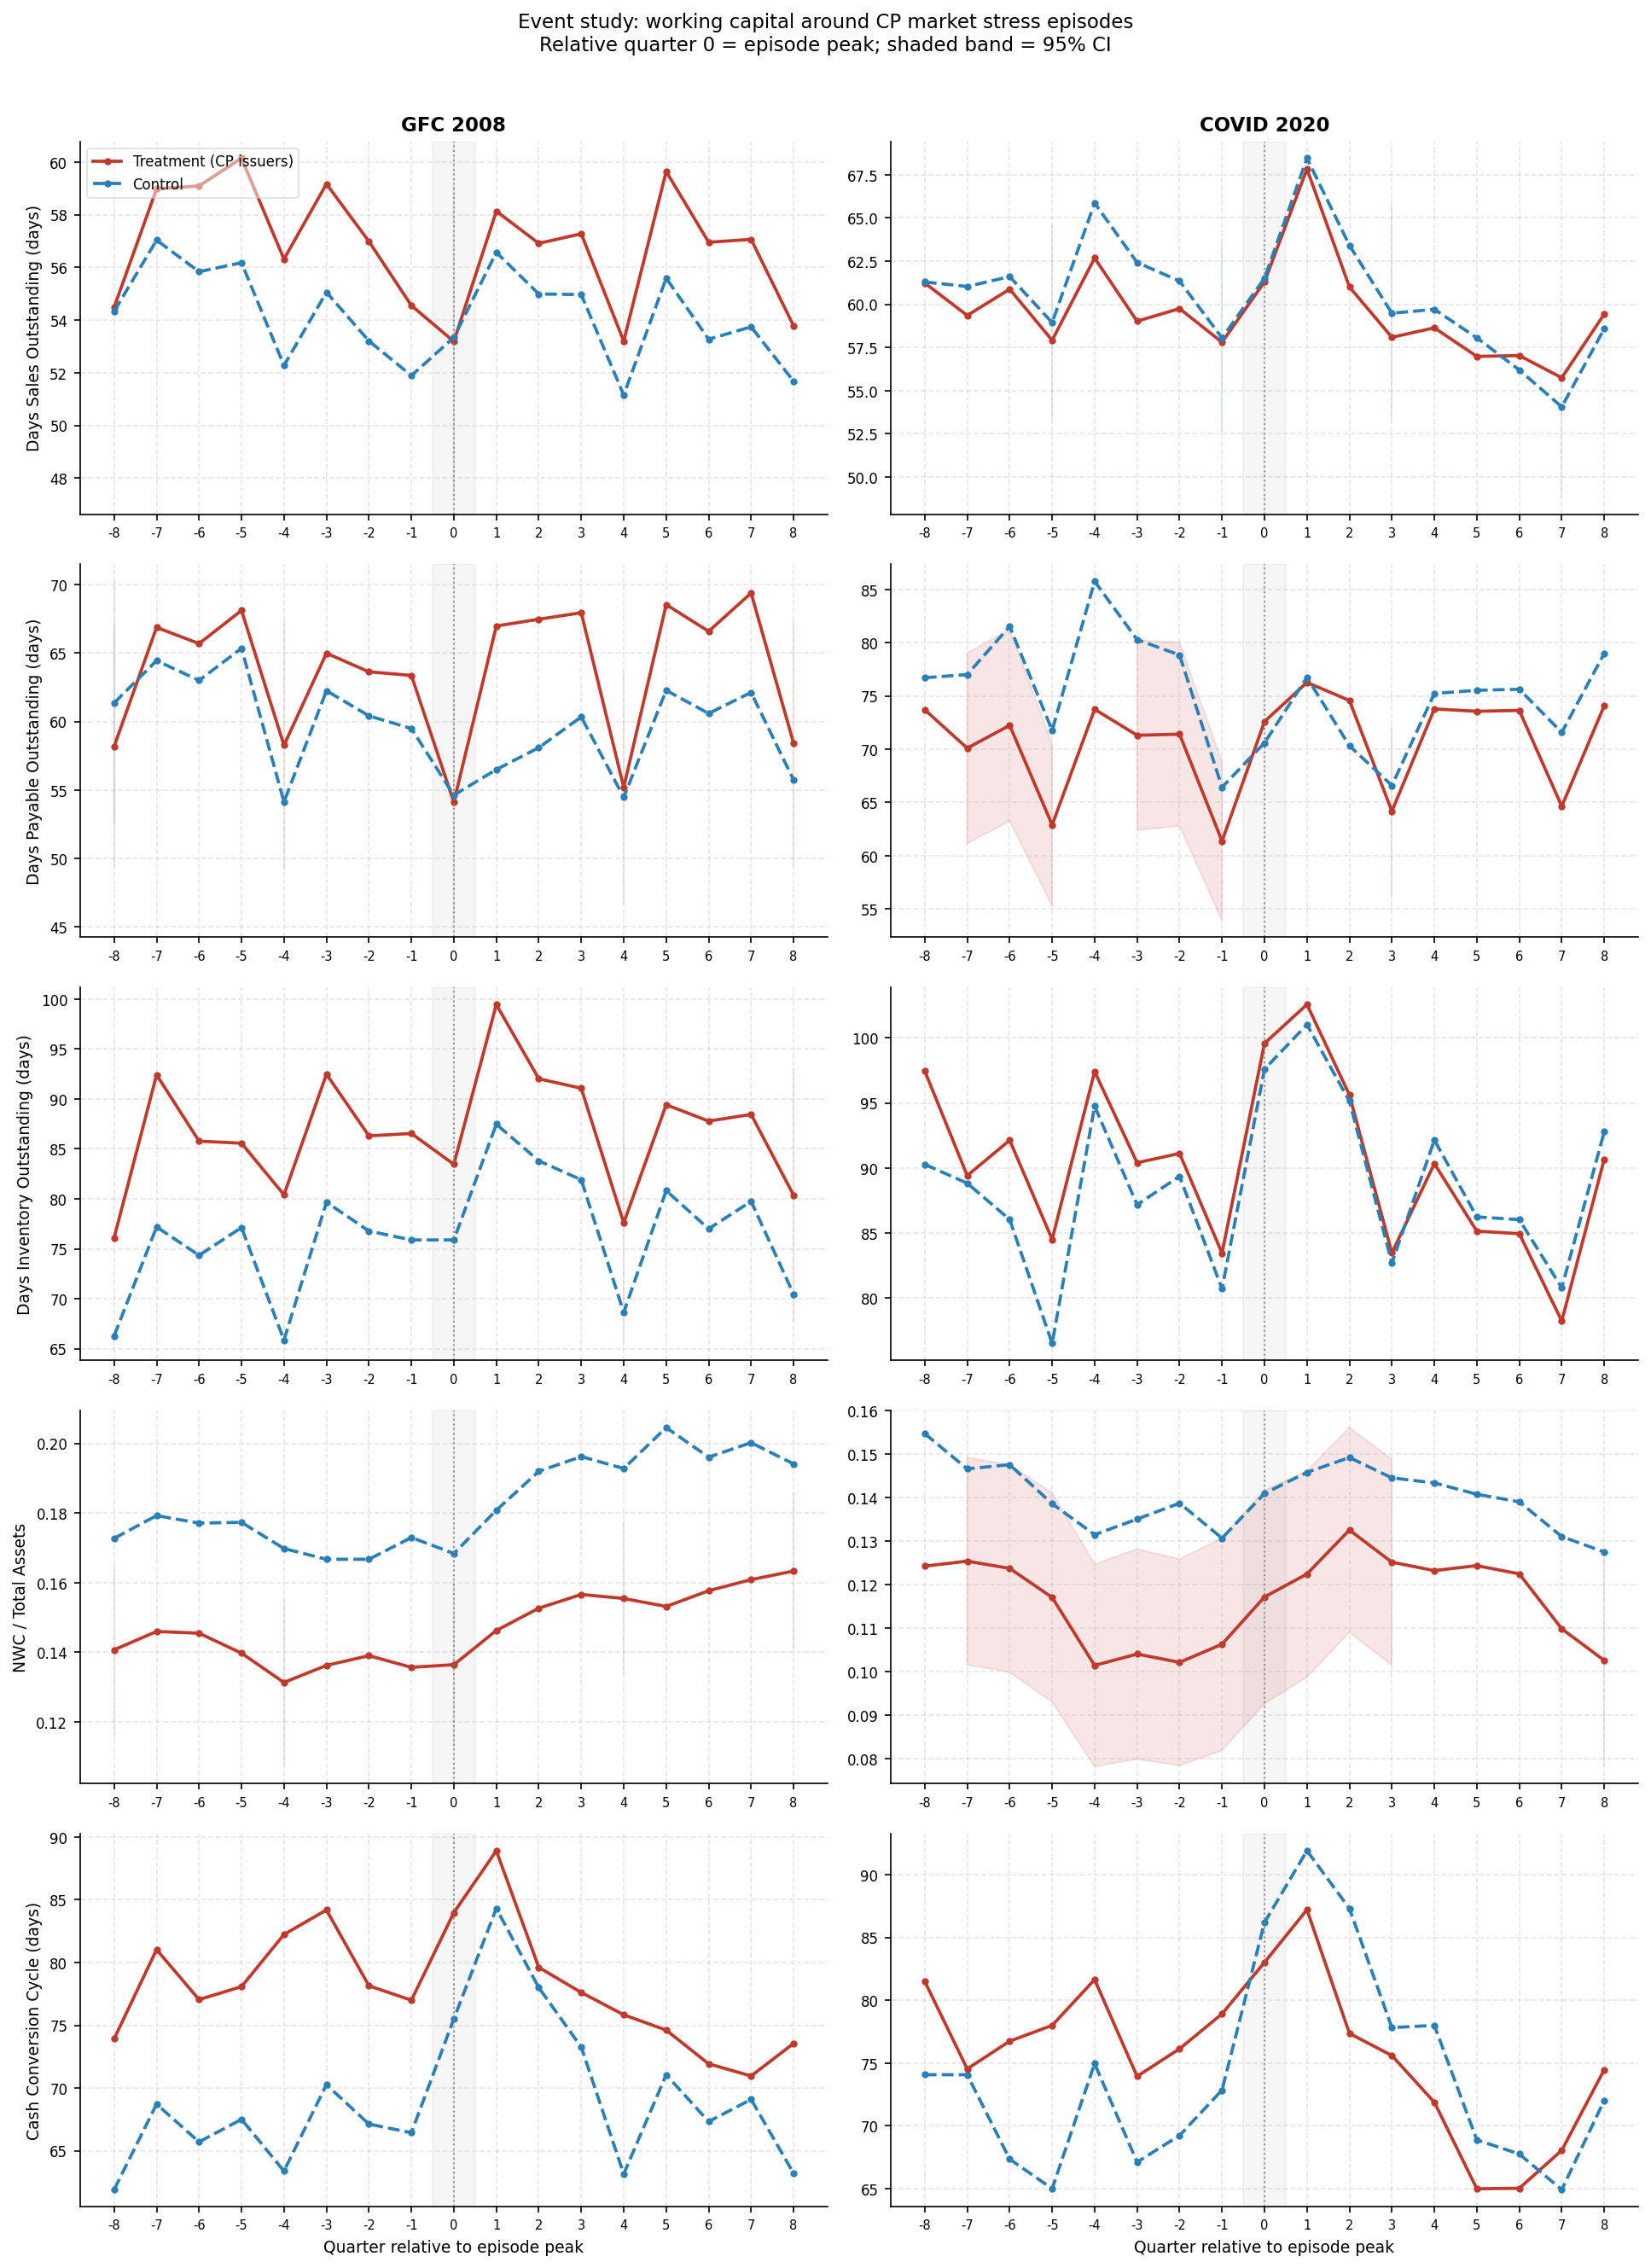

Saved → RE_event_study.png


In [9]:
# CELL 4.2 — Plot outcomes by relative quarter

OUTCOMES_ES = {
    'dso'      : 'Days Sales Outstanding (days)',
    'dpo'      : 'Days Payable Outstanding (days)',
    'dio'      : 'Days Inventory Outstanding (days)',
    'nwc_ratio': 'NWC / Total Assets',
    'ccc'      : 'Cash Conversion Cycle (days)',
}

episodes_to_plot = ['GFC 2008', 'COVID 2020']

fig, axes = plt.subplots(
    nrows=len(OUTCOMES_ES),
    ncols=len(episodes_to_plot),
    figsize=(13, 3.5 * len(OUTCOMES_ES)),
    sharey=False,
)

for col_idx, ep_label in enumerate(episodes_to_plot):
    df = event_datasets[ep_label]

    for row_idx, (var, ylabel) in enumerate(OUTCOMES_ES.items()):
        ax = axes[row_idx, col_idx]

        for group_val, color, linestyle, glabel in [
            (1, COLOR_T, '-',  'Treatment (CP issuers)'),
            (0, COLOR_C, '--', 'Control'),
        ]:
            grp     = df[df['treated'] == group_val]
            stats_q = (
                grp.groupby('rel_q')[var]
                .agg(mean='mean', se=sem)
                .reset_index()
            )
            stats_q = stats_q[stats_q['rel_q'].between(-WINDOW, WINDOW)]

            ax.plot(
                stats_q['rel_q'], stats_q['mean'],
                color=color, linestyle=linestyle,
                linewidth=1.8, marker='o', markersize=3,
                label=glabel,
            )
            ax.fill_between(
                stats_q['rel_q'],
                stats_q['mean'] - 1.96 * stats_q['se'],
                stats_q['mean'] + 1.96 * stats_q['se'],
                alpha=0.12, color=color,
            )

        ax.axvline(0, color='grey', linewidth=1, linestyle=':', alpha=0.8)
        ax.axvspan(-0.5, 0.5, alpha=0.07, color='grey')

        ax.set_xticks(range(-WINDOW, WINDOW + 1))
        ax.set_xticklabels([str(q) for q in range(-WINDOW, WINDOW + 1)], fontsize=7)
        ax.tick_params(axis='y', labelsize=8)

        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if row_idx == 0:
            ax.set_title(ep_label, fontsize=11, fontweight='bold')
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=8, framealpha=0.5, loc='upper left')
        if row_idx == len(OUTCOMES_ES) - 1:
            ax.set_xlabel('Quarter relative to episode peak', fontsize=9)

fig.suptitle(
    'Event study: working capital around CP market stress episodes\n'
    'Relative quarter 0 = episode peak; shaded band = 95% CI',
    fontsize=11, y=1.01,
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'RE_event_study.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → RE_event_study.png")

## Section 5 — Difference-in-Differences

Two-way fixed effects DiD estimates for each working capital outcome, using the matched sample. Binary and continuous CSI specifications are run in parallel; a one-way FE diagnostic checks whether time effects are over-absorbing the stress signal.

`panel_matched` is the preferred sample throughout; `panel_full` is retained for robustness checks

`csi_max` uses the quarterly peak rather than the mean to preserve within-episode spike intensity. β captures the additional WC adjustment per unit increase in peak CSI for CP issuers relative to matched controls.

Two-way FE absorbs all aggregate time variation, which is conservative. Firm FE only leaves the time-series variation in CSI identified. Agreement between the two specs indicates two-way FE is not over-absorbing the stress signal. The preferred spec remains two-way FE.

- **5.1** — Prepare panel indices and interaction terms
- **5.2** — Binary stress indicator
- **5.3** — Continuous CSI intensity
- **5.4** — One-way FE diagnostic

In [10]:
# CELL 5.1 — Prepare panel indices and interaction terms

OUTCOMES_REG = ['dso', 'dpo', 'dio', 'nwc_ratio', 'ccc']

panel['time_idx'] = (panel['fyearq'] - 2000) * 4 + (panel['fqtr'] - 1)

panel['stress_x_treated']  = panel['stress_binary'] * panel['treated']
panel['csi_max_x_treated'] = panel['csi_max']        * panel['treated']

panel_full = panel.set_index(['gvkey', 'time_idx']).sort_index()

panel_matched = panel[panel['in_matched_sample'] == 1].copy()
panel_matched = panel_matched.set_index(['gvkey', 'time_idx']).sort_index()

print(f"Full panel    : {len(panel_full):,} obs | "
      f"{panel_full.index.get_level_values('gvkey').nunique()} firms")
print(f"Matched panel : {len(panel_matched):,} obs | "
      f"{panel_matched.index.get_level_values('gvkey').nunique()} firms")
print(f"\nstress_x_treated == 1  : {(panel['stress_x_treated']==1).sum():,} obs")
print(f"csi_max_x_treated > 0  : {(panel['csi_max_x_treated']>0).sum():,} obs")
print(f"\nTreated firms in matched panel: "
      f"{(panel_matched['treated']==1).sum():,} obs / "
      f"{panel_matched[panel_matched['treated']==1].index.get_level_values('gvkey').nunique()} firms")
print(f"Control firms in matched panel: "
      f"{(panel_matched['treated']==0).sum():,} obs / "
      f"{panel_matched[panel_matched['treated']==0].index.get_level_values('gvkey').nunique()} firms")

Full panel    : 45,465 obs | 550 firms
Matched panel : 40,739 obs | 496 firms

stress_x_treated == 1  : 6,189 obs
csi_max_x_treated > 0  : 21,114 obs

Treated firms in matched panel: 17,271 obs / 191 firms
Control firms in matched panel: 23,468 obs / 305 firms


In [11]:
# CELL 5.2 — Binary stress indicator

results_binary = {}

for outcome in OUTCOMES_REG:
    sub = panel_matched[[outcome, 'stress_x_treated',
                          'log_assets', 'leverage']].dropna()
    mod = PanelOLS.from_formula(
        f'{outcome} ~ stress_x_treated'
        f' + log_assets + leverage'
        f' + EntityEffects + TimeEffects',
        data=sub
    )
    results_binary[outcome] = mod.fit(cov_type='clustered', cluster_entity=True)

print("DiD Results — Binary Stress Indicator (matched sample)")
print("Firm + time fixed effects | Clustered SE (firm level)")
print("=" * 70)
print(f"{'Outcome':<12} {'β (stress×treated)':>20} {'SE':>8} {'t':>7} {'p':>7} {'N':>7}")
print("-" * 70)

for outcome, res in results_binary.items():
    b     = res.params['stress_x_treated']
    se    = res.std_errors['stress_x_treated']
    tstat = res.tstats['stress_x_treated']
    p     = res.pvalues['stress_x_treated']
    n     = int(res.nobs)
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"{outcome:<12} {b:>20.3f}{stars:<3} {se:>8.3f} {tstat:>7.2f} {p:>7.3f} {n:>7,}")

print("\nSignificance: *** p<0.01, ** p<0.05, * p<0.1")
print("Note: stress_binary and treated main effects absorbed by FE — correct")

DiD Results — Binary Stress Indicator (matched sample)
Firm + time fixed effects | Clustered SE (firm level)
Outcome        β (stress×treated)       SE       t       p       N
----------------------------------------------------------------------
dso                        -0.525       0.633   -0.83   0.407  39,523
dpo                         0.513       1.037    0.49   0.621  39,856
dio                        -0.077       0.894   -0.09   0.931  38,949
nwc_ratio                  -0.000       0.002   -0.21   0.838  39,187
ccc                        -0.459       1.151   -0.40   0.690  38,469

Significance: *** p<0.01, ** p<0.05, * p<0.1
Note: stress_binary and treated main effects absorbed by FE — correct


In [12]:
# CELL 5.3 — Continuous CSI intensity

results_csi = {}

for outcome in OUTCOMES_REG:
    sub = panel_matched[[outcome, 'csi_max_x_treated',
                          'log_assets', 'leverage']].dropna()
    mod = PanelOLS.from_formula(
        f'{outcome} ~ csi_max_x_treated'
        f' + log_assets + leverage'
        f' + EntityEffects + TimeEffects',
        data=sub
    )
    results_csi[outcome] = mod.fit(cov_type='clustered', cluster_entity=True)

print("DiD Results — Continuous CSI (matched sample)")
print("Firm + time fixed effects | Clustered SE (firm level)")
print("=" * 70)
print(f"{'Outcome':<12} {'β (csi_max×treated)':>20} {'SE':>8} {'t':>7} {'p':>7} {'N':>7}")
print("-" * 70)

for outcome, res in results_csi.items():
    b     = res.params['csi_max_x_treated']
    se    = res.std_errors['csi_max_x_treated']
    tstat = res.tstats['csi_max_x_treated']
    p     = res.pvalues['csi_max_x_treated']
    n     = int(res.nobs)
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"{outcome:<12} {b:>20.3f}{stars:<3} {se:>8.3f} {tstat:>7.2f} {p:>7.3f} {n:>7,}")

print("\nSignificance: *** p<0.01, ** p<0.05, * p<0.1")

print(f"\nWithin R² comparison:")
print(f"{'Outcome':<12} {'Binary spec':>12} {'CSI spec':>10}")
print("-" * 36)
for outcome in OUTCOMES_REG:
    print(f"{outcome:<12} {results_binary[outcome].rsquared_within:>12.4f} "
          f"{results_csi[outcome].rsquared_within:>10.4f}")

DiD Results — Continuous CSI (matched sample)
Firm + time fixed effects | Clustered SE (firm level)
Outcome       β (csi_max×treated)       SE       t       p       N
----------------------------------------------------------------------
dso                        -0.296       0.284   -1.04   0.297  39,523
dpo                        -0.042       0.562   -0.07   0.941  39,856
dio                        -0.164       0.516   -0.32   0.750  38,949
nwc_ratio                  -0.000       0.001   -0.11   0.911  39,187
ccc                        -0.177       0.663   -0.27   0.790  38,469

Significance: *** p<0.01, ** p<0.05, * p<0.1

Within R² comparison:
Outcome       Binary spec   CSI spec
------------------------------------
dso                0.0067     0.0064
dpo                0.0208     0.0210
dio                0.0238     0.0238
nwc_ratio          0.1412     0.1412
ccc                0.0026     0.0026


In [13]:
# CELL 5.4 — One-way FE diagnostic

results_fe1_binary = {}
results_fe1_csi    = {}

for outcome in OUTCOMES_REG:
    sub = panel_matched[[outcome, 'stress_x_treated', 'stress_binary',
                          'log_assets', 'leverage']].dropna()
    mod = PanelOLS.from_formula(
        f'{outcome} ~ stress_x_treated + stress_binary'
        f' + log_assets + leverage + EntityEffects',
        data=sub
    )
    results_fe1_binary[outcome] = mod.fit(cov_type='clustered', cluster_entity=True)

    sub = panel_matched[[outcome, 'csi_max_x_treated', 'csi_max',
                          'log_assets', 'leverage']].dropna()
    mod = PanelOLS.from_formula(
        f'{outcome} ~ csi_max_x_treated + csi_max'
        f' + log_assets + leverage + EntityEffects',
        data=sub
    )
    results_fe1_csi[outcome] = mod.fit(cov_type='clustered', cluster_entity=True)

print("One-way FE diagnostic (firm FE only) — Binary stress")
print("=" * 70)
print(f"{'Outcome':<12} {'β (stress×treated)':>20} {'SE':>8} {'t':>7} {'p':>7}")
print("-" * 70)
for outcome, res in results_fe1_binary.items():
    b     = res.params['stress_x_treated']
    se    = res.std_errors['stress_x_treated']
    tstat = res.tstats['stress_x_treated']
    p     = res.pvalues['stress_x_treated']
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"{outcome:<12} {b:>20.3f}{stars:<3} {se:>8.3f} {tstat:>7.2f} {p:>7.3f}")

print("\nOne-way FE diagnostic (firm FE only) — Continuous CSI")
print("=" * 70)
print(f"{'Outcome':<12} {'β (csi_max×treated)':>20} {'SE':>8} {'t':>7} {'p':>7}")
print("-" * 70)
for outcome, res in results_fe1_csi.items():
    b     = res.params['csi_max_x_treated']
    se    = res.std_errors['csi_max_x_treated']
    tstat = res.tstats['csi_max_x_treated']
    p     = res.pvalues['csi_max_x_treated']
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"{outcome:<12} {b:>20.3f}{stars:<3} {se:>8.3f} {tstat:>7.2f} {p:>7.3f}")

print("\nSignificance: *** p<0.01, ** p<0.05, * p<0.1")

One-way FE diagnostic (firm FE only) — Binary stress
Outcome        β (stress×treated)       SE       t       p
----------------------------------------------------------------------
dso                        -0.472       0.629   -0.75   0.454
dpo                         0.594       1.033    0.58   0.565
dio                        -0.007       0.897   -0.01   0.994
nwc_ratio                  -0.000       0.002   -0.05   0.963
ccc                        -0.445       1.141   -0.39   0.697

One-way FE diagnostic (firm FE only) — Continuous CSI
Outcome       β (csi_max×treated)       SE       t       p
----------------------------------------------------------------------
dso                        -0.241       0.284   -0.85   0.396
dpo                         0.020       0.556    0.04   0.971
dio                        -0.114       0.517   -0.22   0.826
nwc_ratio                  -0.000       0.001   -0.01   0.989
ccc                        -0.159       0.657   -0.24   0.809

Significanc

## Section 6 — Heterogeneity Analysis

CSI spec estimated separately across subgroups defined by financial flexibility, firm size, industry, and stress episode. All splits use the matched sample and continuous CSI specification from Section 5.

Pre-2007 medians are used for the flexibility and size splits to avoid contamination by the stress episodes themselves.

- **6.1** — Financial flexibility (EBITDA margin, pre-2007 median)
- **6.2** — Firm size (log assets, pre-2007 median)
- **6.3** — Industry (manufacturing vs non-manufacturing)
- **6.4** — Episode (GFC 2008 vs COVID 2020)

In [14]:
# CELL 6.1 — Financial flexibility (EBITDA margin, pre-2007 median)

pre_crisis = panel[panel['fyearq'] <= 2006].copy()
pre_crisis['ebitda_margin'] = pre_crisis['ebitda'] / pre_crisis['revenue'].replace(0, np.nan)

firm_ebitda = (
    pre_crisis[pre_crisis['treated'] == 1]
    .groupby('gvkey')['ebitda_margin']
    .median()
    .reset_index()
    .rename(columns={'ebitda_margin': 'median_ebitda_margin'})
)

median_split = firm_ebitda['median_ebitda_margin'].median()
firm_ebitda['flexible'] = (firm_ebitda['median_ebitda_margin'] >= median_split).astype(int)

print(f"EBITDA margin split (treatment firms only):")
print(f"  Median EBITDA margin       : {median_split:.3f}")
print(f"  High flexibility (≥ median): {firm_ebitda['flexible'].sum()} firms")
print(f"  Low flexibility  (< median): {(firm_ebitda['flexible']==0).sum()} firms")

panel = panel.merge(firm_ebitda[['gvkey', 'flexible']], on='gvkey', how='left')

results_hetero = {}

for flex_label, flex_val in [('High flexibility', 1), ('Low flexibility', 0)]:
    sub_gvkeys = firm_ebitda[firm_ebitda['flexible'] == flex_val]['gvkey'].tolist()
    sub_panel  = panel[
        (panel['treated'] == 0) |
        (panel['gvkey'].isin(sub_gvkeys))
    ].copy()
    sub_panel = sub_panel[sub_panel['in_matched_sample'] == 1].set_index(
        ['gvkey', 'time_idx']
    ).sort_index()

    results_hetero[flex_label] = {}
    for outcome in OUTCOMES_REG:
        sub = sub_panel[[outcome, 'csi_max_x_treated',
                          'log_assets', 'leverage']].dropna()
        mod = PanelOLS.from_formula(
            f'{outcome} ~ csi_max_x_treated'
            f' + log_assets + leverage'
            f' + EntityEffects + TimeEffects',
            data=sub
        )
        results_hetero[flex_label][outcome] = mod.fit(
            cov_type='clustered', cluster_entity=True
        )

print(f"\nHeterogeneity by financial flexibility (EBITDA margin, pre-2007 median)")
print(f"Continuous CSI spec | Firm + time FE | Clustered SE")
print("=" * 80)
print(f"{'Outcome':<12} {'High flex β':>12} {'p':>7} {'Low flex β':>12} {'p':>7} {'Diff':>10}")
print("-" * 80)

for outcome in OUTCOMES_REG:
    rh = results_hetero['High flexibility'][outcome]
    rl = results_hetero['Low flexibility'][outcome]
    bh = rh.params['csi_max_x_treated']
    bl = rl.params['csi_max_x_treated']
    ph = rh.pvalues['csi_max_x_treated']
    pl = rl.pvalues['csi_max_x_treated']
    sh = '***' if ph<0.01 else '**' if ph<0.05 else '*' if ph<0.1 else ''
    sl = '***' if pl<0.01 else '**' if pl<0.05 else '*' if pl<0.1 else ''
    print(f"{outcome:<12} {bh:>12.3f}{sh:<3} {ph:>7.3f} {bl:>12.3f}{sl:<3} {pl:>7.3f} {bl-bh:>10.3f}")

print("\nSignificance: *** p<0.01, ** p<0.05, * p<0.1")
print("Note: controls are the same matched pool in both subgroups")

EBITDA margin split (treatment firms only):
  Median EBITDA margin       : 0.161
  High flexibility (≥ median): 115 firms
  Low flexibility  (< median): 115 firms

Heterogeneity by financial flexibility (EBITDA margin, pre-2007 median)
Continuous CSI spec | Firm + time FE | Clustered SE
Outcome       High flex β       p   Low flex β       p       Diff
--------------------------------------------------------------------------------
dso                -0.201      0.623       -0.428      0.165     -0.227
dpo                -0.133      0.871        0.002      0.997      0.135
dio                 0.343      0.621       -0.617      0.293     -0.960
nwc_ratio          -0.000      0.907        0.000      0.837      0.000
ccc                 0.582      0.536       -0.884      0.179     -1.467

Significance: *** p<0.01, ** p<0.05, * p<0.1
Note: controls are the same matched pool in both subgroups


In [15]:
# CELL 6.2 — Firm size (log assets, pre-2007 median)

firm_size = (
    panel[(panel['fyearq'] <= 2006) & (panel['treated'] == 1)]
    .groupby('gvkey')['log_assets']
    .median()
    .reset_index()
    .rename(columns={'log_assets': 'median_log_assets'})
)

size_split = firm_size['median_log_assets'].median()
firm_size['large'] = (firm_size['median_log_assets'] >= size_split).astype(int)

print(f"Size split (treatment firms only):")
print(f"  Median log assets  : {size_split:.3f} (assets ~ ${np.exp(size_split)/1000:.1f}bn)")
print(f"  Large (≥ median)   : {firm_size['large'].sum()} firms")
print(f"  Small (< median)   : {(firm_size['large']==0).sum()} firms")

panel = panel.merge(firm_size[['gvkey', 'large']], on='gvkey', how='left')

results_size = {}

for size_label, size_val in [('Large firms', 1), ('Small firms', 0)]:
    sub_gvkeys = firm_size[firm_size['large'] == size_val]['gvkey'].tolist()
    sub_panel  = panel[
        (panel['treated'] == 0) |
        (panel['gvkey'].isin(sub_gvkeys))
    ].copy()
    sub_panel = sub_panel[sub_panel['in_matched_sample'] == 1].set_index(
        ['gvkey', 'time_idx']
    ).sort_index()

    results_size[size_label] = {}
    for outcome in OUTCOMES_REG:
        sub = sub_panel[[outcome, 'csi_max_x_treated',
                          'log_assets', 'leverage']].dropna()
        mod = PanelOLS.from_formula(
            f'{outcome} ~ csi_max_x_treated'
            f' + log_assets + leverage'
            f' + EntityEffects + TimeEffects',
            data=sub
        )
        results_size[size_label][outcome] = mod.fit(
            cov_type='clustered', cluster_entity=True
        )

print(f"\nHeterogeneity by firm size (log assets, pre-2007 median)")
print(f"Continuous CSI spec | Firm + time FE | Clustered SE")
print("=" * 80)
print(f"{'Outcome':<12} {'Large β':>12} {'p':>7} {'Small β':>12} {'p':>7} {'Diff':>10}")
print("-" * 80)

for outcome in OUTCOMES_REG:
    rl = results_size['Large firms'][outcome]
    rs = results_size['Small firms'][outcome]
    bl = rl.params['csi_max_x_treated']
    bs = rs.params['csi_max_x_treated']
    pl = rl.pvalues['csi_max_x_treated']
    ps = rs.pvalues['csi_max_x_treated']
    sl = '***' if pl<0.01 else '**' if pl<0.05 else '*' if pl<0.1 else ''
    ss = '***' if ps<0.01 else '**' if ps<0.05 else '*' if ps<0.1 else ''
    print(f"{outcome:<12} {bl:>12.3f}{sl:<3} {pl:>7.3f} {bs:>12.3f}{ss:<3} {ps:>7.3f} {bs-bl:>10.3f}")

print("\nSignificance: *** p<0.01, ** p<0.05, * p<0.1")

Size split (treatment firms only):
  Median log assets  : 8.785 (assets ~ $6.5bn)
  Large (≥ median)   : 115 firms
  Small (< median)   : 115 firms

Heterogeneity by firm size (log assets, pre-2007 median)
Continuous CSI spec | Firm + time FE | Clustered SE
Outcome           Large β       p      Small β       p       Diff
--------------------------------------------------------------------------------
dso                -0.431      0.266       -0.222      0.518      0.208
dpo                -0.109      0.865       -0.038      0.957      0.071
dio                 0.388      0.627       -0.535      0.314     -0.923
nwc_ratio           0.001      0.663       -0.000      0.832     -0.001
ccc                 0.333      0.696       -0.496      0.526     -0.829

Significance: *** p<0.01, ** p<0.05, * p<0.1


In [16]:
# CELL 6.3 — Industry (SIC 2000–3999 = manufacturing)

sic_map = (
    master[['gvkey', 'sic']]
    .drop_duplicates('gvkey')
    .copy()
)
sic_map['manufacturing'] = (
    (sic_map['sic'] >= 2000) & (sic_map['sic'] <= 3999)
).astype(int)

print("Industry split (treatment firms):")
print(
    sic_map[sic_map['gvkey'].isin(panel[panel['treated']==1]['gvkey'].unique())]
    ['manufacturing'].value_counts()
    .rename({1: 'Manufacturing', 0: 'Non-manufacturing'})
)

panel = panel.merge(sic_map[['gvkey', 'manufacturing']], on='gvkey', how='left')

results_industry = {}

for ind_label, ind_val in [('Manufacturing', 1), ('Non-manufacturing', 0)]:
    sub_gvkeys = sic_map[sic_map['manufacturing'] == ind_val]['gvkey'].tolist()
    sub_panel  = panel[
        (panel['treated'] == 0) |
        (panel['gvkey'].isin(sub_gvkeys))
    ].copy()
    sub_panel = sub_panel[sub_panel['in_matched_sample'] == 1].set_index(
        ['gvkey', 'time_idx']
    ).sort_index()

    results_industry[ind_label] = {}
    for outcome in OUTCOMES_REG:
        sub = sub_panel[[outcome, 'csi_max_x_treated',
                          'log_assets', 'leverage']].dropna()
        mod = PanelOLS.from_formula(
            f'{outcome} ~ csi_max_x_treated'
            f' + log_assets + leverage'
            f' + EntityEffects + TimeEffects',
            data=sub
        )
        results_industry[ind_label][outcome] = mod.fit(
            cov_type='clustered', cluster_entity=True
        )

print(f"\nHeterogeneity by industry (SIC 2000–3999 = manufacturing)")
print(f"Continuous CSI spec | Firm + time FE | Clustered SE")
print("=" * 80)
print(f"{'Outcome':<12} {'Manuf. β':>12} {'p':>7} {'Non-manuf. β':>14} {'p':>7} {'Diff':>10}")
print("-" * 80)

for outcome in OUTCOMES_REG:
    rm = results_industry['Manufacturing'][outcome]
    rn = results_industry['Non-manufacturing'][outcome]
    bm = rm.params['csi_max_x_treated']
    bn = rn.params['csi_max_x_treated']
    pm = rm.pvalues['csi_max_x_treated']
    pn = rn.pvalues['csi_max_x_treated']
    sm = '***' if pm<0.01 else '**' if pm<0.05 else '*' if pm<0.1 else ''
    sn = '***' if pn<0.01 else '**' if pn<0.05 else '*' if pn<0.1 else ''
    print(f"{outcome:<12} {bm:>12.3f}{sm:<3} {pm:>7.3f} {bn:>14.3f}{sn:<3} {pn:>7.3f} {bm-bn:>10.3f}")

print("\nSignificance: *** p<0.01, ** p<0.05, * p<0.1")

Industry split (treatment firms):
manufacturing
Manufacturing        152
Non-manufacturing     93
Name: count, dtype: int64

Heterogeneity by industry (SIC 2000–3999 = manufacturing)
Continuous CSI spec | Firm + time FE | Clustered SE
Outcome          Manuf. β       p   Non-manuf. β       p       Diff
--------------------------------------------------------------------------------
dso                 0.047      0.880         -0.807*     0.060      0.854
dpo                 0.319      0.533         -0.576      0.540      0.895
dio                 0.158      0.804         -0.633      0.274      0.791
nwc_ratio          -0.000      0.782          0.000      0.906     -0.000
ccc                 0.023      0.975         -0.469      0.614      0.492

Significance: *** p<0.01, ** p<0.05, * p<0.1


In [17]:
# CELL 6.4 — Episode (GFC 2008 vs COVID 2020)

results_episode = {}

for ep_label in ['GFC 2008', 'COVID 2020']:
    df = event_datasets[ep_label][
        event_datasets[ep_label]['in_matched_sample'] == 1
    ].copy()
    df['time_idx']          = (df['fyearq'] - 2000) * 4 + (df['fqtr'] - 1)
    df['csi_max_x_treated'] = df['csi_max'] * df['treated']
    df = df.set_index(['gvkey', 'time_idx']).sort_index()

    results_episode[ep_label] = {}
    for outcome in OUTCOMES_REG:
        sub = df[[outcome, 'csi_max_x_treated',
                   'log_assets', 'leverage']].dropna()
        mod = PanelOLS.from_formula(
            f'{outcome} ~ csi_max_x_treated'
            f' + log_assets + leverage'
            f' + EntityEffects + TimeEffects',
            data=sub
        )
        results_episode[ep_label][outcome] = mod.fit(
            cov_type='clustered', cluster_entity=True
        )

print(f"Heterogeneity by episode: GFC 2008 vs COVID 2020")
print(f"±8 quarter window | Continuous CSI | Firm + time FE | Clustered SE")
print("=" * 80)
print(f"{'Outcome':<12} {'GFC β':>12} {'p':>7} {'COVID β':>12} {'p':>7} {'Diff':>10}")
print("-" * 80)

for outcome in OUTCOMES_REG:
    rg = results_episode['GFC 2008'][outcome]
    rc = results_episode['COVID 2020'][outcome]
    bg = rg.params['csi_max_x_treated']
    bc = rc.params['csi_max_x_treated']
    pg = rg.pvalues['csi_max_x_treated']
    pc = rc.pvalues['csi_max_x_treated']
    sg = '***' if pg<0.01 else '**' if pg<0.05 else '*' if pg<0.1 else ''
    sc = '***' if pc<0.01 else '**' if pc<0.05 else '*' if pc<0.1 else ''
    print(f"{outcome:<12} {bg:>12.3f}{sg:<3} {pg:>7.3f} {bc:>12.3f}{sc:<3} {pc:>7.3f} {bg-bc:>10.3f}")

print("\nSignificance: *** p<0.01, ** p<0.05, * p<0.1")

Heterogeneity by episode: GFC 2008 vs COVID 2020
±8 quarter window | Continuous CSI | Firm + time FE | Clustered SE
Outcome             GFC β       p      COVID β       p       Diff
--------------------------------------------------------------------------------
dso                -0.044      0.896       -0.228      0.565      0.184
dpo                -0.210      0.698        0.817      0.250     -1.027
dio                -0.631      0.275        0.187      0.833     -0.818
nwc_ratio           0.001      0.588       -0.000      0.999      0.001
ccc                -0.299      0.661       -1.064      0.322      0.765

Significance: *** p<0.01, ** p<0.05, * p<0.1


## Section 7 — Liquidity Substitution

Within-firm regressions testing whether CP stress predicts revolver drawdowns among treatment firms. Treatment firms only — controls have no CP program and provide no substitution counterfactual.

Dollar variables are log-transformed as log(1+x); coefficients read as semi-elasticities. `statsmodels` OLS with explicit dummies is used in place of `linearmodels` PanelOLS, which produces nonsensical coefficients for this panel structure.

- **7.1** — Within-firm substitution regressions
- **7.2** — CP outstanding vs revolver drawdowns around stress episodes
- **7.3** — Interest cost channel

In [18]:
# CELL 7.1 — Within-firm substitution regressions

OUTCOMES_SUB = {
    'log_revolver_drawn'  : 'log(1 + Revolver drawn)',
    'revolver_utilization': 'Revolver utilization (ratio)',
    'log_cp_outstanding'  : 'log(1 + CP outstanding)',
}

treat_panel = panel[
    (panel['treated'] == 1) &
    (panel['in_matched_sample'] == 1)
].copy()

treat_panel = treat_panel.drop_duplicates(subset=['gvkey', 'time_idx'])
treat_panel['log_revolver_drawn'] = np.log1p(treat_panel['ciq_revolver_drawn'])
treat_panel['log_cp_outstanding'] = np.log1p(treat_panel['ciq_cp_outstanding'])

print(f"Treatment firms for substitution test: "
      f"{treat_panel['gvkey'].nunique()} firms | {len(treat_panel):,} obs")
print()
for outcome, label in OUTCOMES_SUB.items():
    n_valid = treat_panel[[outcome]].dropna().shape[0]
    pct     = n_valid / len(treat_panel) * 100
    print(f"  {outcome:<25}: {n_valid:,} obs ({pct:.1f}% coverage)")

treat_matched = treat_panel.set_index(['gvkey', 'time_idx']).sort_index()

def run_twoway_fe(data, outcome, regressor):
    sub = data[[outcome, regressor]].dropna().reset_index()
    mod = smf.ols(
        f'{outcome} ~ {regressor} + C(gvkey) + C(time_idx)',
        data=sub
    )
    res = mod.fit(cov_type='cluster', cov_kwds={'groups': sub['gvkey']})
    return (
        res.params[regressor],
        res.bse[regressor],
        res.tvalues[regressor],
        res.pvalues[regressor],
        int(res.nobs),
    )

print(f"\nWithin-firm substitution — Binary stress indicator")
print(f"Firm + time FE | Clustered SE | Treatment firms only")
print("=" * 70)
print(f"{'Outcome':<28} {'β (stress)':>12} {'SE':>8} {'t':>7} {'p':>7} {'N':>7}")
print("-" * 70)

results_sub_binary = {}
for outcome, label in OUTCOMES_SUB.items():
    b, se, tstat, p, n = run_twoway_fe(treat_matched, outcome, 'stress_binary')
    stars = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"{label:<28} {b:>12.3f}{stars:<3} {se:>8.3f} {tstat:>7.2f} {p:>7.3f} {n:>7,}")
    results_sub_binary[outcome] = (b, se, tstat, p, n)

print(f"\nWithin-firm substitution — Continuous CSI (csi_max)")
print(f"Firm + time FE | Clustered SE | Treatment firms only")
print("=" * 70)
print(f"{'Outcome':<28} {'β (csi_max)':>12} {'SE':>8} {'t':>7} {'p':>7} {'N':>7}")
print("-" * 70)

results_sub_csi = {}
for outcome, label in OUTCOMES_SUB.items():
    b, se, tstat, p, n = run_twoway_fe(treat_matched, outcome, 'csi_max')
    stars = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"{label:<28} {b:>12.3f}{stars:<3} {se:>8.3f} {tstat:>7.2f} {p:>7.3f} {n:>7,}")
    results_sub_csi[outcome] = (b, se, tstat, p, n)

print("\nSignificance: *** p<0.01, ** p<0.05, * p<0.1")
print("Note: dollar variables transformed as log(1+x); coefficients are semi-elasticities")

Treatment firms for substitution test: 191 firms | 17,264 obs

  log_revolver_drawn       : 10,753 obs (62.3% coverage)
  revolver_utilization     : 9,751 obs (56.5% coverage)
  log_cp_outstanding       : 8,569 obs (49.6% coverage)

Within-firm substitution — Binary stress indicator
Firm + time FE | Clustered SE | Treatment firms only
Outcome                        β (stress)       SE       t       p       N
----------------------------------------------------------------------
log(1 + Revolver drawn)            -1.390***    0.275   -5.05   0.000  10,753
Revolver utilization (ratio)       -0.456***    0.046   -9.89   0.000   9,751
log(1 + CP outstanding)            -0.822       0.992   -0.83   0.407   8,569

Within-firm substitution — Continuous CSI (csi_max)
Firm + time FE | Clustered SE | Treatment firms only
Outcome                       β (csi_max)       SE       t       p       N
----------------------------------------------------------------------
log(1 + Revolver drawn)        

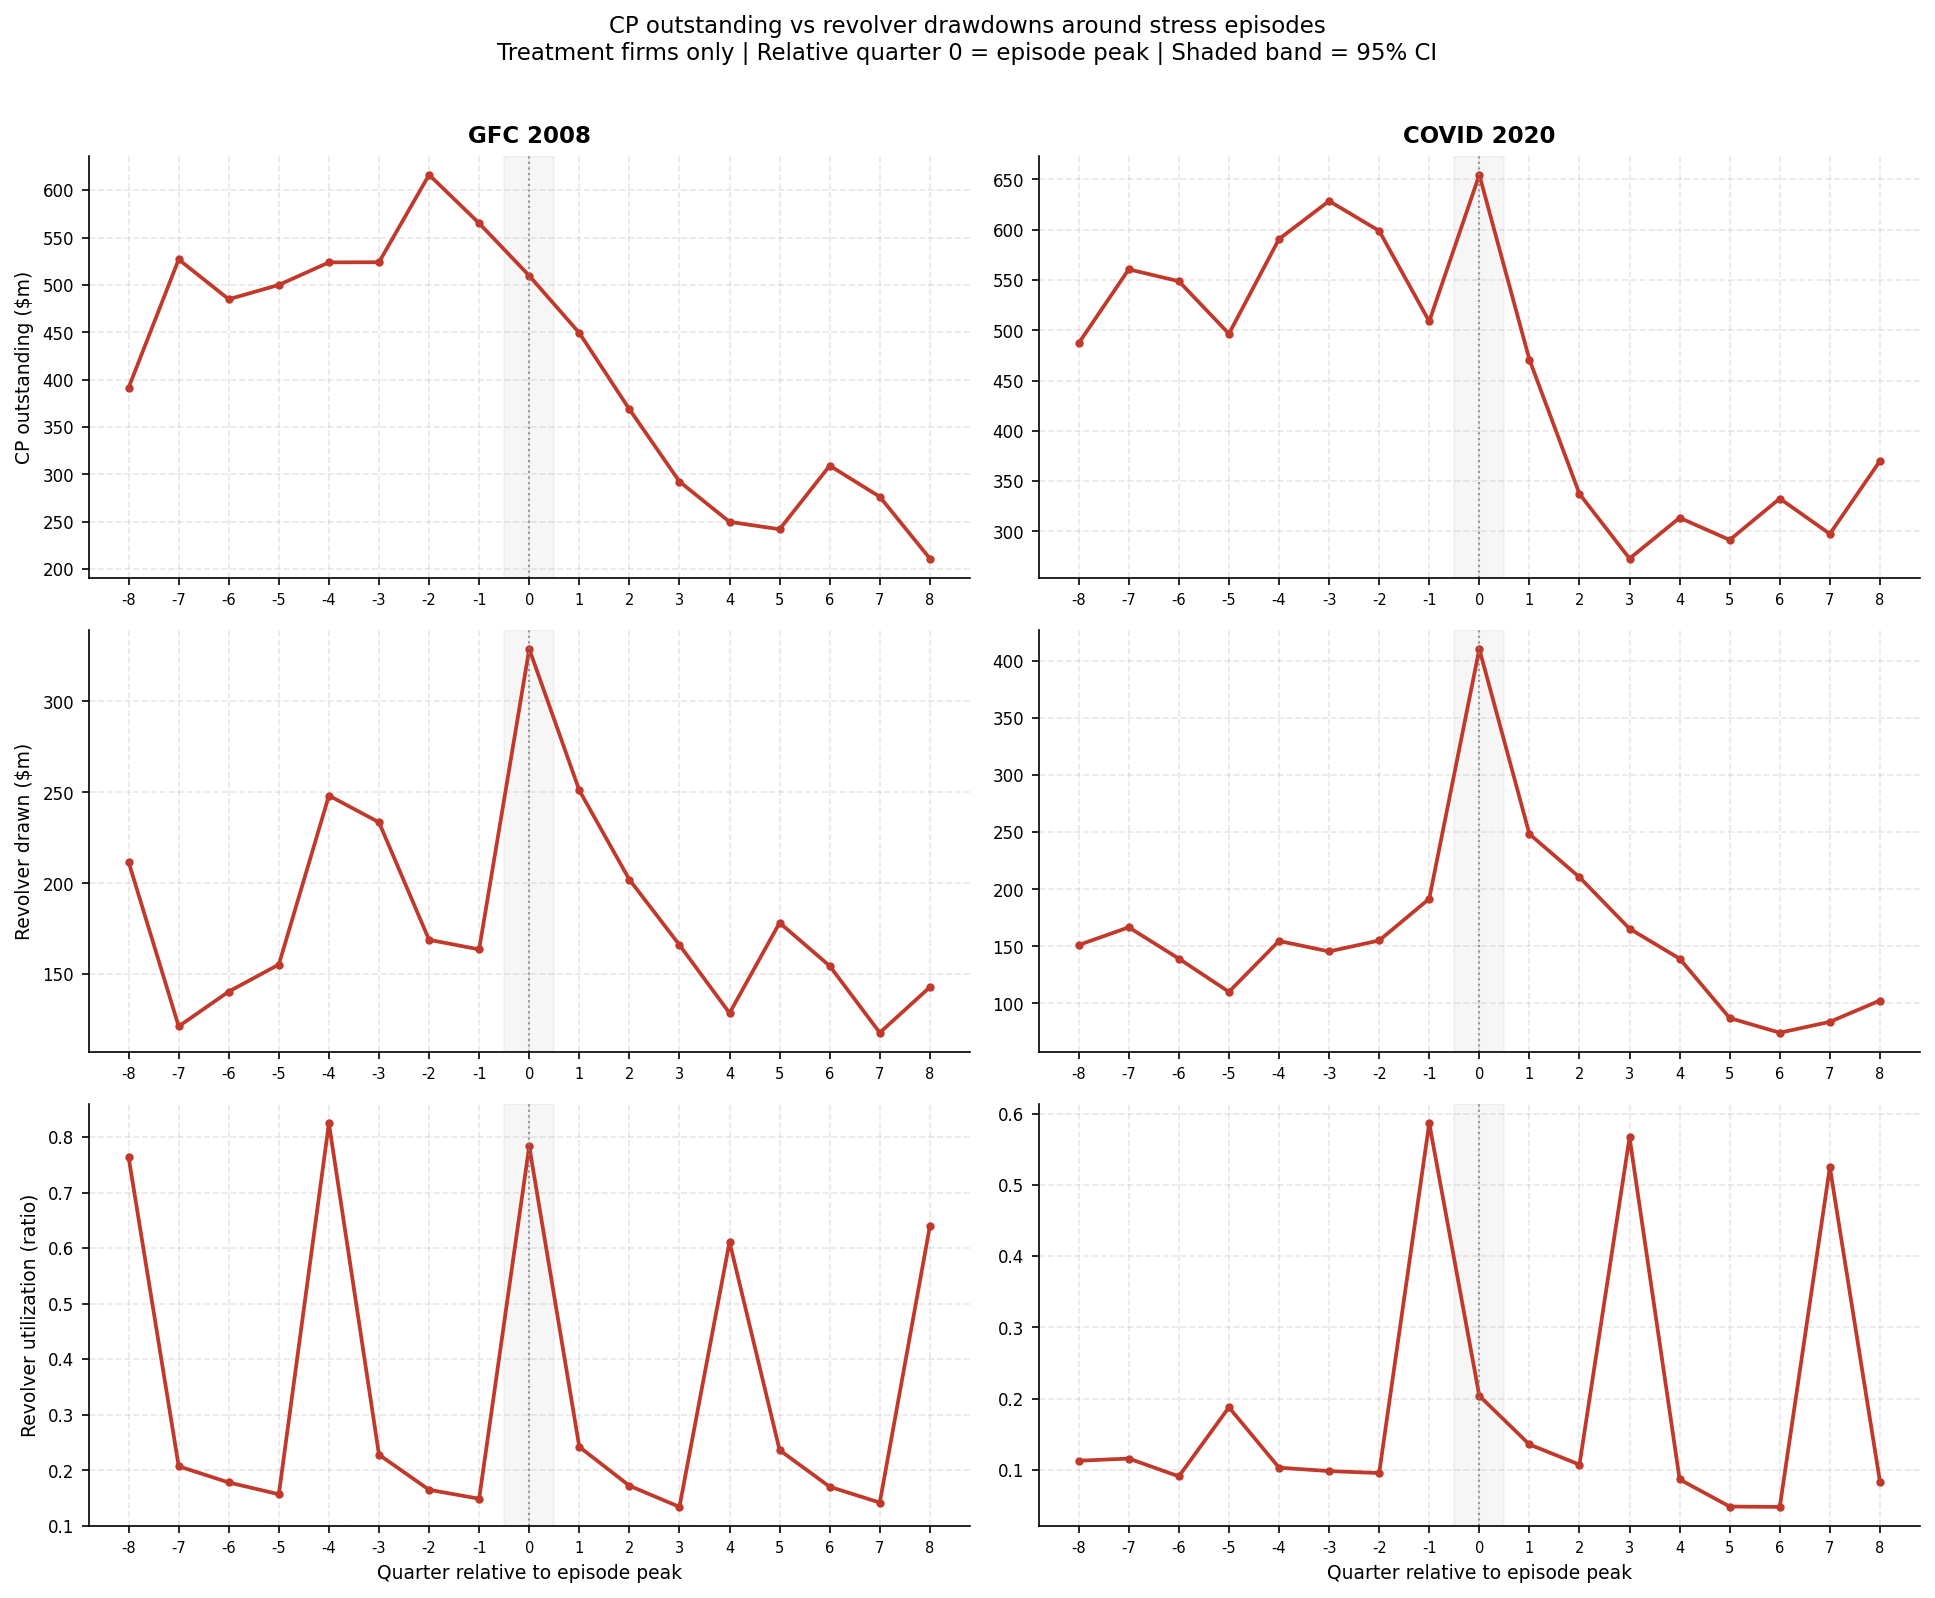

Saved → RE_substitution_event_study.png


In [19]:
# CELL 7.2 — CP outstanding vs revolver drawdowns around stress episodes

OUTCOMES_SUB_ES = {
    'ciq_cp_outstanding'  : 'CP outstanding ($m)',
    'ciq_revolver_drawn'  : 'Revolver drawn ($m)',
    'revolver_utilization': 'Revolver utilization (ratio)',
}

episodes_to_plot = ['GFC 2008', 'COVID 2020']

fig, axes = plt.subplots(
    nrows=len(OUTCOMES_SUB_ES),
    ncols=len(episodes_to_plot),
    figsize=(13, 3.5 * len(OUTCOMES_SUB_ES)),
    sharey=False,
)

for col_idx, ep_label in enumerate(episodes_to_plot):
    df       = event_datasets[ep_label]
    df_treat = df[df['treated'] == 1]

    for row_idx, (var, ylabel) in enumerate(OUTCOMES_SUB_ES.items()):
        ax = axes[row_idx, col_idx]

        stats_q = (
            df_treat.groupby('rel_q')[var]
            .agg(mean='mean', se=sem)
            .reset_index()
        )
        stats_q = stats_q[stats_q['rel_q'].between(-WINDOW, WINDOW)]

        ax.plot(
            stats_q['rel_q'], stats_q['mean'],
            color=COLOR_T, linestyle='-',
            linewidth=1.8, marker='o', markersize=3,
        )
        ax.fill_between(
            stats_q['rel_q'],
            stats_q['mean'] - 1.96 * stats_q['se'],
            stats_q['mean'] + 1.96 * stats_q['se'],
            alpha=0.15, color=COLOR_T,
        )

        ax.axvline(0, color='grey', linewidth=1, linestyle=':', alpha=0.8)
        ax.axvspan(-0.5, 0.5, alpha=0.07, color='grey')

        ax.set_xticks(range(-WINDOW, WINDOW + 1))
        ax.set_xticklabels(
            [str(q) for q in range(-WINDOW, WINDOW + 1)], fontsize=7
        )
        ax.tick_params(axis='y', labelsize=8)

        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if row_idx == 0:
            ax.set_title(ep_label, fontsize=11, fontweight='bold')
        if row_idx == len(OUTCOMES_SUB_ES) - 1:
            ax.set_xlabel('Quarter relative to episode peak', fontsize=9)

fig.suptitle(
    'CP outstanding vs revolver drawdowns around stress episodes\n'
    'Treatment firms only | Relative quarter 0 = episode peak | Shaded band = 95% CI',
    fontsize=11, y=1.01,
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'RE_substitution_event_study.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → RE_substitution_event_study.png")

In [45]:
# CELL 7.3 — Interest cost channel

matched = panel[panel['in_matched_sample'] == 1].copy()
matched['log_interest_paid'] = np.log1p(matched['interest_paid'])
matched_idx = matched.set_index(['gvkey', 'time_idx']).sort_index()

print(f"Matched sample: {matched[matched['treated']==1]['gvkey'].nunique()} treatment | "
      f"{matched[matched['treated']==0]['gvkey'].nunique()} control | {len(matched):,} obs")

def run_did_fe(data, outcome, regressor):
    sub = data[[outcome, regressor, 'treated', 'log_assets', 'leverage']].dropna().reset_index()
    interact = f'{regressor}_x_treated'
    sub[interact] = sub[regressor] * sub['treated']
    res = smf.ols(
        f'{outcome} ~ {interact} + {regressor} + treated + log_assets + leverage'
        f' + C(gvkey) + C(time_idx)',
        data=sub
    ).fit(cov_type='cluster', cov_kwds={'groups': sub['gvkey']})
    return res.params[interact], res.bse[interact], res.tvalues[interact], res.pvalues[interact], int(res.nobs)

for spec_label, regressor in [
    ('Binary stress indicator', 'stress_binary'),
    ('Continuous CSI (csi_max)', 'csi_max'),
]:
    print(f"\nInterest cost channel — {spec_label}")
    print(f"Two-way FE DiD | Clustered SE (firm) | Matched sample")
    print("=" * 70)
    print(f"{'Outcome':<28} {'β (stress×treated)':>18} {'SE':>8} {'t':>7} {'p':>7} {'N':>8}")
    print("-" * 70)
    b, se, t, p, n = run_did_fe(matched_idx, 'log_interest_paid', regressor)
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"{'log(1 + Interest paid)':<28} {b:>18.4f}{stars:<3} {se:>8.4f} {t:>7.2f} {p:>7.3f} {n:>8,}")

print("\nSignificance: *** p<0.01, ** p<0.05, * p<0.1")
print("Controls: log(total assets), leverage | Firm + time fixed effects")

Matched sample: 191 treatment | 305 control | 40,739 obs

Interest cost channel — Binary stress indicator
Two-way FE DiD | Clustered SE (firm) | Matched sample
Outcome                      β (stress×treated)       SE       t       p        N
----------------------------------------------------------------------
log(1 + Interest paid)                   0.0351***   0.0102    3.42   0.001   38,138

Interest cost channel — Continuous CSI (csi_max)
Two-way FE DiD | Clustered SE (firm) | Matched sample
Outcome                      β (stress×treated)       SE       t       p        N
----------------------------------------------------------------------
log(1 + Interest paid)                   0.0110**    0.0049    2.24   0.025   38,138

Significance: *** p<0.01, ** p<0.05, * p<0.1
Controls: log(total assets), leverage | Firm + time fixed effects


## Section 8 — Robustness

Parallel trends test, lagged stress specifications, and replication on the full unmatched panel.

- **8.1** — Parallel trends test
- **8.2** — Lagged stress effects
- **8.3** — Full unmatched panel

In [46]:
# CELL 8.1 — Parallel trends test

PRE_WINDOW = 8

print("Formal parallel trends test")
print("H0: no differential pre-trend (treated × rel_q insignificant)")
print("Pre-episode window: rel_q = -8 to -1 | Clustered SE (firm)")
print("=" * 70)
print(f"{'Outcome':<12} {'Episode':>12} {'β treat×rel_q':>15} {'p':>8} {'Result':>12}")
print("-" * 70)

for ep_label, ep_df in event_datasets.items():
    pre = ep_df[
        ep_df['rel_q'].between(-PRE_WINDOW, -1) &
        (ep_df['in_matched_sample'] == 1)
    ].copy()

    for outcome in OUTCOMES_REG:
        sub = pre[['gvkey', 'rel_q', 'treated', outcome]].dropna()
        if len(sub) < 20:
            continue

        model = smf.ols(
            f'{outcome} ~ treated * rel_q + C(rel_q)',
            data=sub
        ).fit()

        cov  = cov_cluster(model, sub['gvkey'].values)
        se   = np.sqrt(np.diag(cov))
        idx  = list(model.params.index).index('treated:rel_q')
        b    = model.params['treated:rel_q']
        s    = se[idx]
        p    = 2 * (1 - t_dist.cdf(abs(b / s), df=sub['gvkey'].nunique() - 1))
        flag = '✓ parallel' if p > 0.1 else '△ review'
        print(f"{outcome:<12} {ep_label:>12} {b:>15.4f} {p:>8.3f} {flag:>12}")

print("\n✓ parallel = p > 0.1 | △ review = p ≤ 0.1, inspect visually")

Formal parallel trends test
H0: no differential pre-trend (treated × rel_q insignificant)
Pre-episode window: rel_q = -8 to -1 | Clustered SE (firm)
Outcome           Episode   β treat×rel_q        p       Result
----------------------------------------------------------------------
dso              GFC 2008          0.3556    0.307   ✓ parallel
dpo              GFC 2008          0.6622    0.259   ✓ parallel
dio              GFC 2008         -0.1392    0.844   ✓ parallel
nwc_ratio        GFC 2008          0.0001    0.923   ✓ parallel
ccc              GFC 2008         -0.0010    0.999   ✓ parallel
dso            COVID 2020         -0.1355    0.734   ✓ parallel
dpo            COVID 2020         -0.2397    0.753   ✓ parallel
dio            COVID 2020         -0.4654    0.510   ✓ parallel
nwc_ratio      COVID 2020         -0.0011    0.406   ✓ parallel
ccc            COVID 2020          0.1036    0.923   ✓ parallel

✓ parallel = p > 0.1 | △ review = p ≤ 0.1, inspect visually


In [47]:
# CELL 8.2 — Lagged stress effects

panel_lag = panel[panel['in_matched_sample'] == 1].copy()
panel_lag = panel_lag.sort_values(['gvkey', 'time_idx'])

for lag in [0, 1, 2]:
    panel_lag[f'stress_x_treated_L{lag}'] = (
        panel_lag.groupby('gvkey')['stress_binary']
        .shift(lag)
        .mul(panel_lag['treated'])
    )

panel_lag = panel_lag.set_index(['gvkey', 'time_idx']).sort_index()

lag_results = {lag: {} for lag in [0, 1, 2]}

for lag in [0, 1, 2]:
    var = f'stress_x_treated_L{lag}'
    for outcome in OUTCOMES_REG:
        sub = panel_lag[[outcome, var, 'log_assets', 'leverage']].dropna()
        try:
            mod = PanelOLS.from_formula(
                f'{outcome} ~ {var} + log_assets + leverage'
                f' + EntityEffects + TimeEffects',
                data=sub
            )
            res = mod.fit(cov_type='clustered', cluster_entity=True)
            lag_results[lag][outcome] = {
                'b': res.params[var],
                'p': res.pvalues[var],
                'n': int(res.nobs),
            }
        except Exception:
            lag_results[lag][outcome] = {'b': np.nan, 'p': np.nan, 'n': 0}

print("Lagged stress effects (matched sample, two-way FE)")
print("=" * 75)
header = f"{'Outcome':<12}"
for lag in [0, 1, 2]:
    header += f"  {'β L'+str(lag):>8}  {'p':>6}  {'N':>6}"
print(header)
print("-" * 75)

for outcome in OUTCOMES_REG:
    row = f"{outcome:<12}"
    for lag in [0, 1, 2]:
        r     = lag_results[lag][outcome]
        stars = '***' if r['p']<0.01 else '**' if r['p']<0.05 else '*' if r['p']<0.1 else ''
        b_str = f"{r['b']:.3f}{stars}" if not np.isnan(r['b']) else '—'
        p_str = f"{r['p']:.3f}"        if not np.isnan(r['p']) else '—'
        row  += f"  {b_str:>10}  {p_str:>6}  {r['n']:>6}"
    print(row)

print("\nSignificance: *** p<0.01, ** p<0.05, * p<0.1")
print("Controls: log_assets, leverage | FE: firm + time | SE: clustered (firm)")

Lagged stress effects (matched sample, two-way FE)
Outcome           β L0       p       N      β L1       p       N      β L2       p       N
---------------------------------------------------------------------------
dso               -0.525   0.407   39523      -0.242   0.691   39129      -0.579   0.332   38731
dpo                0.510   0.623   39856       0.709   0.514   39465       0.818   0.446   39063
dio               -0.080   0.928   38949       0.354   0.720   38561      -0.333   0.734   38162
nwc_ratio         -0.001   0.630   38367      -0.001   0.609   37987      -0.000   0.953   37604
ccc               -0.460   0.690   38469      -0.131   0.917   38089      -1.288   0.316   37698

Significance: *** p<0.01, ** p<0.05, * p<0.1
Controls: log_assets, leverage | FE: firm + time | SE: clustered (firm)


In [48]:
# CELL 8.3 — Full unmatched panel

results_full_binary = {}
results_full_csi    = {}

for outcome in OUTCOMES_REG:
    sub = panel_full[[outcome, 'stress_x_treated',
                       'log_assets', 'leverage']].dropna()
    mod = PanelOLS.from_formula(
        f'{outcome} ~ stress_x_treated + log_assets + leverage'
        f' + EntityEffects + TimeEffects',
        data=sub
    )
    results_full_binary[outcome] = mod.fit(cov_type='clustered', cluster_entity=True)

    sub = panel_full[[outcome, 'csi_max_x_treated',
                       'log_assets', 'leverage']].dropna()
    mod = PanelOLS.from_formula(
        f'{outcome} ~ csi_max_x_treated + log_assets + leverage'
        f' + EntityEffects + TimeEffects',
        data=sub
    )
    results_full_csi[outcome] = mod.fit(cov_type='clustered', cluster_entity=True)

for spec_label, res_matched, res_full, var in [
    ('Binary stress',  results_binary,  results_full_binary, 'stress_x_treated'),
    ('Continuous CSI', results_csi,     results_full_csi,    'csi_max_x_treated'),
]:
    print(f"Robustness: matched vs full panel — {spec_label}")
    print(f"Firm + time FE | Clustered SE")
    print("=" * 75)
    print(f"{'Outcome':<12} {'Matched β':>12} {'p':>7} {'Full panel β':>14} {'p':>7} {'Verdict':>12}")
    print("-" * 75)

    for outcome in OUTCOMES_REG:
        rm = res_matched[outcome]
        rf = res_full[outcome]
        bm = rm.params[var];  pm = rm.pvalues[var]
        bf = rf.params[var];  pf = rf.pvalues[var]
        sm = '***' if pm<0.01 else '**' if pm<0.05 else '*' if pm<0.1 else ''
        sf = '***' if pf<0.01 else '**' if pf<0.05 else '*' if pf<0.1 else ''
        verdict = '✓ robust' if (pm<0.1 and pf<0.1) else '✓ null holds' if (pm>0.1 and pf>0.1) else '△ diverges'
        print(f"{outcome:<12} {bm:>12.3f}{sm:<3} {pm:>7.3f} {bf:>14.3f}{sf:<3} {pf:>7.3f} {verdict:>12}")

    print("\nSignificance: *** p<0.01, ** p<0.05, * p<0.1\n")

Robustness: matched vs full panel — Binary stress
Firm + time FE | Clustered SE
Outcome         Matched β       p   Full panel β       p      Verdict
---------------------------------------------------------------------------
dso                -0.525      0.407         -0.454      0.436 ✓ null holds
dpo                 0.510      0.623          0.090      0.930 ✓ null holds
dio                -0.080      0.928         -0.149      0.861 ✓ null holds
nwc_ratio          -0.001      0.630         -0.001      0.719 ✓ null holds
ccc                -0.460      0.690          0.103      0.927 ✓ null holds

Significance: *** p<0.01, ** p<0.05, * p<0.1

Robustness: matched vs full panel — Continuous CSI
Firm + time FE | Clustered SE
Outcome         Matched β       p   Full panel β       p      Verdict
---------------------------------------------------------------------------
dso                -0.296      0.297         -0.311      0.231 ✓ null holds
dpo                -0.043      0.939        